In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12,6)

# Cargar y preparar datos
df = pd.read_csv('../data/df_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.asfreq('h')

target = 'pm10_openmeteo'
exog_vars = ['temperature_openmeteo','relativehumidity_openmeteo','windspeed_openmeteo',
             'pressure_openmeteo','precipitation_openmeteo','no2_openmeteo']

series = df[target].dropna()
df_exog = df[exog_vars].loc[series.index].ffill().bfill()

# Dividir en train/test
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]
exog_train = df_exog.iloc[:train_size]
exog_test = df_exog.iloc[train_size:]

# INICIALIZAR RESULTADOS - ESTO FALTABA
resultados = []

print("=== ANÁLISIS EXPLORATORIO ===")
print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Rango temporal: {series.index.min()} a {series.index.max()}")
print(f"Variables exógenas: {exog_vars}")

=== ANÁLISIS EXPLORATORIO ===
Train: 22428, Test: 5607
Rango temporal: 2022-08-03 21:00:00+00:00 a 2025-10-14 23:00:00+00:00
Variables exógenas: ['temperature_openmeteo', 'relativehumidity_openmeteo', 'windspeed_openmeteo', 'pressure_openmeteo', 'precipitation_openmeteo', 'no2_openmeteo']


=== MODELO PROPHET CORREGIDO ===
Entrenando Prophet (sin timezone)...


15:28:01 - cmdstanpy - INFO - Chain [1] start processing
15:28:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet con regresores - MAE: 3.61, RMSE: 5.13


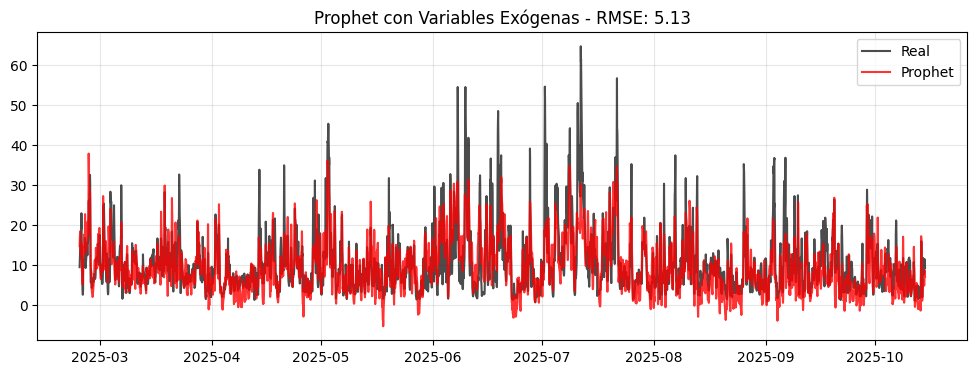

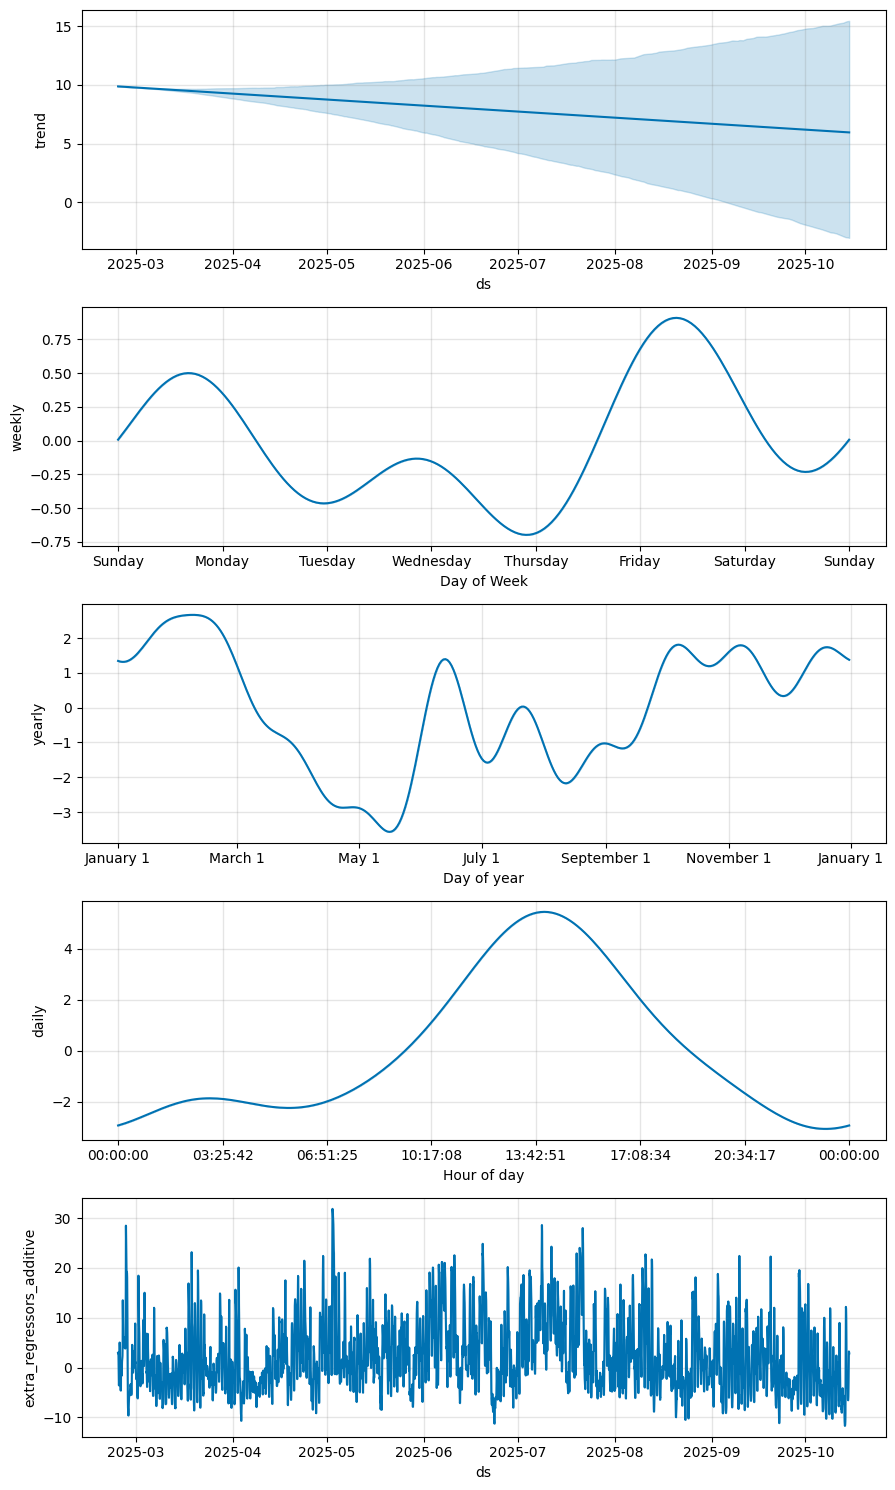

3520

In [ ]:
print("=== MODELO PROPHET ===")
from prophet import Prophet
import gc

try:
    print("Entrenando Prophet")
    
    # Preparar datos para Prophet (sin timezone)
    df_prophet = train.reset_index()
    df_prophet.columns = ['ds', 'y']
    
    # Eliminar timezone info
    df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)
    
    # Crear y entrenar modelo
    prophet_model = Prophet(
        daily_seasonality=True,
        yearly_seasonality=True,
        weekly_seasonality=True,
        changepoint_prior_scale=0.05
    )
    
    # Añadir regresores (variables exógenas)
    for var in exog_vars:
        df_prophet[var] = exog_train[var].values
        prophet_model.add_regressor(var)
    
    prophet_model.fit(df_prophet)
    
    # Crear dataframe futuro
    future = prophet_model.make_future_dataframe(periods=len(test), freq='H', include_history=False)
    
    # Añadir variables exógenas al futuro
    for var in exog_vars:
        future[var] = exog_test[var].values
    
    # Predecir
    forecast = prophet_model.predict(future)
    
    # Extraer predicciones
    pred_prophet = forecast['yhat'].values
    
    mae = mean_absolute_error(test, pred_prophet)
    rmse = np.sqrt(mean_squared_error(test, pred_prophet))
    
    print(f"Prophet con regresores - MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
    # Gráfica
    plt.figure(figsize=(12,4))
    plt.plot(test.index, test.values, label='Real', color='black', alpha=0.7)
    plt.plot(test.index, pred_prophet, label='Prophet', color='red', alpha=0.8)
    plt.title(f'Prophet con Variables Exógenas - RMSE: {rmse:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Guardar resultado
    resultados.append({'Modelo': 'Prophet con regresores', 'MAE': mae, 'RMSE': rmse})
    
    # Mostrar componentes
    try:
        fig_components = prophet_model.plot_components(forecast)
        plt.show()
    except:
        print("No se pudieron mostrar los componentes de Prophet")
    
except Exception as e:
    print(f"Error en Prophet: {e}")

gc.collect()

=== BENCHMARKS BÁSICOS ===
1. Persistencia - MAE: 5.08, RMSE: 8.10
2. Media Histórica - MAE: 6.14, RMSE: 7.87
3. Media por Hora - MAE: 5.88, RMSE: 7.60


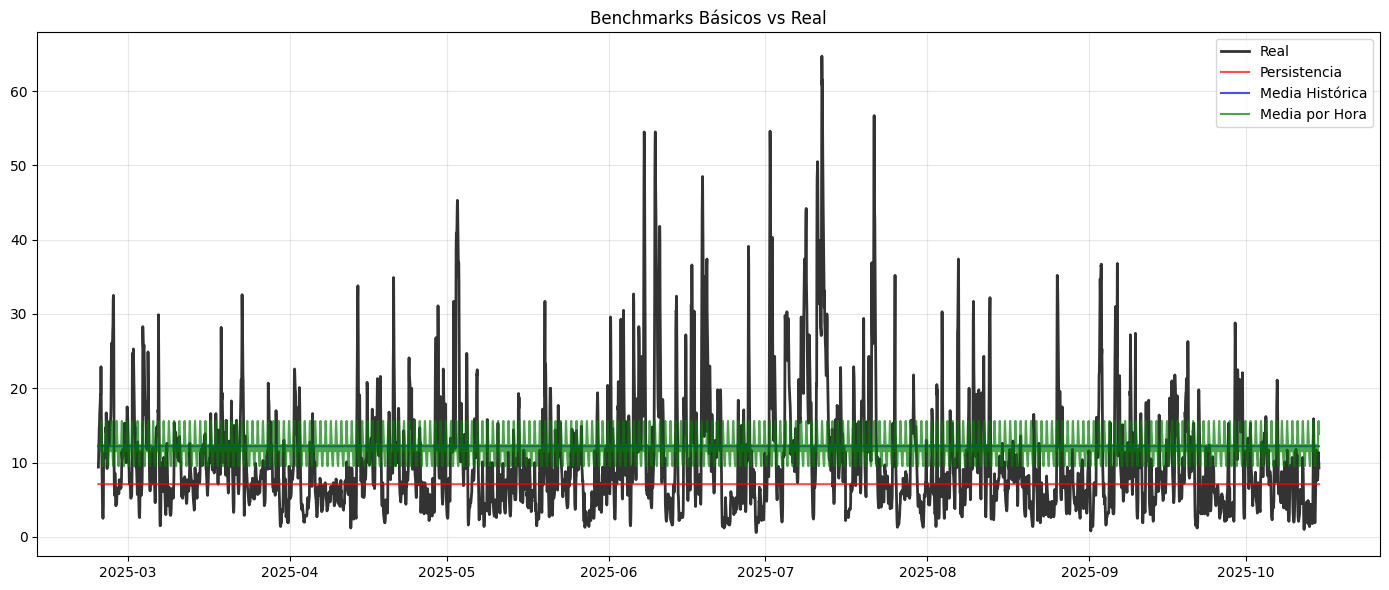

3852

In [17]:
print("=== BENCHMARKS BÁSICOS ===")
import gc

# 1. Persistencia (último valor)
pred_persistence = np.full(len(test), train.iloc[-1])
mae_pers = mean_absolute_error(test, pred_persistence)
rmse_pers = np.sqrt(mean_squared_error(test, pred_persistence))
print(f"1. Persistencia - MAE: {mae_pers:.2f}, RMSE: {rmse_pers:.2f}")

# 2. Media histórica
pred_mean = np.full(len(test), train.mean())
mae_mean = mean_absolute_error(test, pred_mean)
rmse_mean = np.sqrt(mean_squared_error(test, pred_mean))
print(f"2. Media Histórica - MAE: {mae_mean:.2f}, RMSE: {rmse_mean:.2f}")

# 3. Media por hora del día
def media_por_hora(series, test_len):
    """Predice usando la media histórica para cada hora del día"""
    # Calcular media por hora
    media_hora = series.groupby(series.index.hour).mean()
    
    predictions = []
    for i in range(test_len):
        hora = (test.index[0] + pd.Timedelta(hours=i)).hour
        predictions.append(media_hora.get(hora, series.mean()))
    
    return np.array(predictions)

pred_hora = media_por_hora(train, len(test))
mae_hora = mean_absolute_error(test, pred_hora)
rmse_hora = np.sqrt(mean_squared_error(test, pred_hora))
print(f"3. Media por Hora - MAE: {mae_hora:.2f}, RMSE: {rmse_hora:.2f}")

# Guardar resultados de benchmarks
resultados.extend([
    {'Modelo': 'Persistencia', 'MAE': mae_pers, 'RMSE': rmse_pers},
    {'Modelo': 'Media Histórica', 'MAE': mae_mean, 'RMSE': rmse_mean},
    {'Modelo': 'Media por Hora', 'MAE': mae_hora, 'RMSE': rmse_hora}
])

# Gráfica de benchmarks
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, label='Real', color='black', linewidth=2, alpha=0.8)

benchmarks = {
    'Persistencia': pred_persistence,
    'Media Histórica': pred_mean,
    'Media por Hora': pred_hora
}

colors = ['red', 'blue', 'green']
for i, (nombre, pred) in enumerate(benchmarks.items()):
    plt.plot(test.index, pred, label=nombre, color=colors[i], alpha=0.7, linewidth=1.5)

plt.title('Benchmarks Básicos vs Real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gc.collect()

=== RANDOM FOREST CON CARACTERÍSTICAS TEMPORALES ===
Creando características temporales...
Features creadas: 29 variables
Filas de entrenamiento: 22260
Entrenando Random Forest...
Random Forest - MAE: 0.22, RMSE: 0.50

Top 10 características más importantes:
            feature  importance
21   rolling_mean_3    0.934216
22    rolling_std_3    0.029420
15            lag_2    0.028715
14            lag_1    0.002701
16            lag_3    0.001195
24    rolling_std_6    0.000570
13    no2_openmeteo    0.000447
26   rolling_std_12    0.000277
25  rolling_mean_12    0.000246
4          hour_sin    0.000194


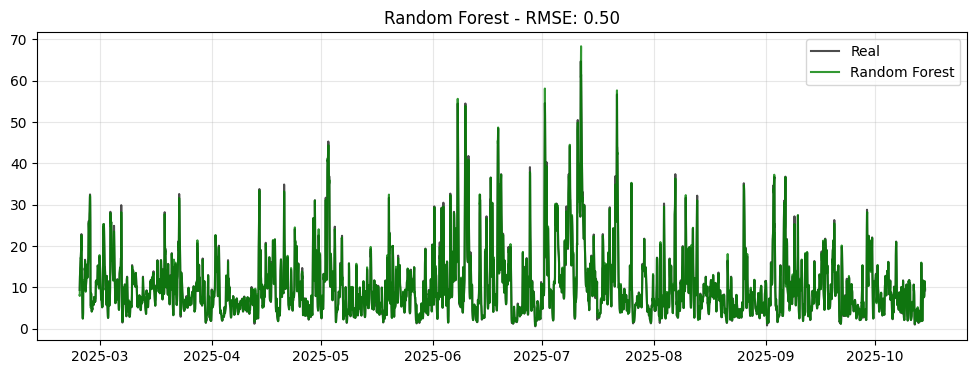

3605

In [18]:
print("=== RANDOM FOREST CON CARACTERÍSTICAS TEMPORALES ===")
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import gc

try:
    print("Creando características temporales...")
    
    def crear_features_temporales(series, exog_df):
        features = pd.DataFrame(index=series.index)
        
        # Características temporales básicas
        features['hour'] = series.index.hour
        features['day_of_week'] = series.index.dayofweek
        features['month'] = series.index.month
        features['day_of_year'] = series.index.dayofyear
        
        # Features cíclicas
        features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
        features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)
        features['day_sin'] = np.sin(2 * np.pi * features['day_of_week'] / 7)
        features['day_cos'] = np.cos(2 * np.pi * features['day_of_week'] / 7)
        
        # Variables exógenas
        for col in exog_df.columns:
            features[col] = exog_df[col]
        
        # Lags (valores pasados)
        for lag in [1, 2, 3, 24, 25, 26, 168]:  # 1h, 2h, 3h, 24h, 25h, 26h, 1 semana
            features[f'lag_{lag}'] = series.shift(lag)
        
        # Medias móviles
        for window in [3, 6, 12, 24]:
            features[f'rolling_mean_{window}'] = series.rolling(window).mean()
            features[f'rolling_std_{window}'] = series.rolling(window).std()
        
        return features
    
    # Crear features
    X_train_rf = crear_features_temporales(train, exog_train)
    X_test_rf = crear_features_temporales(test, exog_test)
    
    # Eliminar NaNs (debido a los lags)
    valid_idx = X_train_rf.notna().all(axis=1)
    X_train_rf = X_train_rf[valid_idx]
    y_train_rf = train[valid_idx]
    X_test_rf = X_test_rf.fillna(method='ffill')
    
    print(f"Features creadas: {X_train_rf.shape[1]} variables")
    print(f"Filas de entrenamiento: {X_train_rf.shape[0]}")
    
    # Entrenar Random Forest
    print("Entrenando Random Forest...")
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_rf, y_train_rf)
    pred_rf = rf_model.predict(X_test_rf)
    
    mae = mean_absolute_error(test, pred_rf)
    rmse = np.sqrt(mean_squared_error(test, pred_rf))
    
    print(f"Random Forest - MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
    # Importancia de características
    feature_importance = pd.DataFrame({
        'feature': X_train_rf.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 características más importantes:")
    print(feature_importance.head(10))
    
    # Gráfica
    plt.figure(figsize=(12,4))
    plt.plot(test.index, test.values, label='Real', color='black', alpha=0.7)
    plt.plot(test.index, pred_rf, label='Random Forest', color='green', alpha=0.8)
    plt.title(f'Random Forest - RMSE: {rmse:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    resultados.append({'Modelo': 'Random Forest', 'MAE': mae, 'RMSE': rmse})
    
except Exception as e:
    print(f"Error en Random Forest: {e}")

gc.collect()

=== COMPARACIÓN FINAL ===

COMPARACIÓN DE MODELOS (ordenados por RMSE)
                   Modelo     MAE    RMSE
4           Random Forest  0.2229  0.4979
0  Prophet con regresores  3.6138  5.1286
3          Media por Hora  5.8813  7.6021
2         Media Histórica  6.1351  7.8736
1            Persistencia  5.0826  8.1024

🏆 RESUMEN:
MEJOR MODELO: Random Forest
  - RMSE: 0.50
  - MAE: 0.22
BENCHMARK (Persistencia): RMSE = 8.10
MEJORA: +93.9%


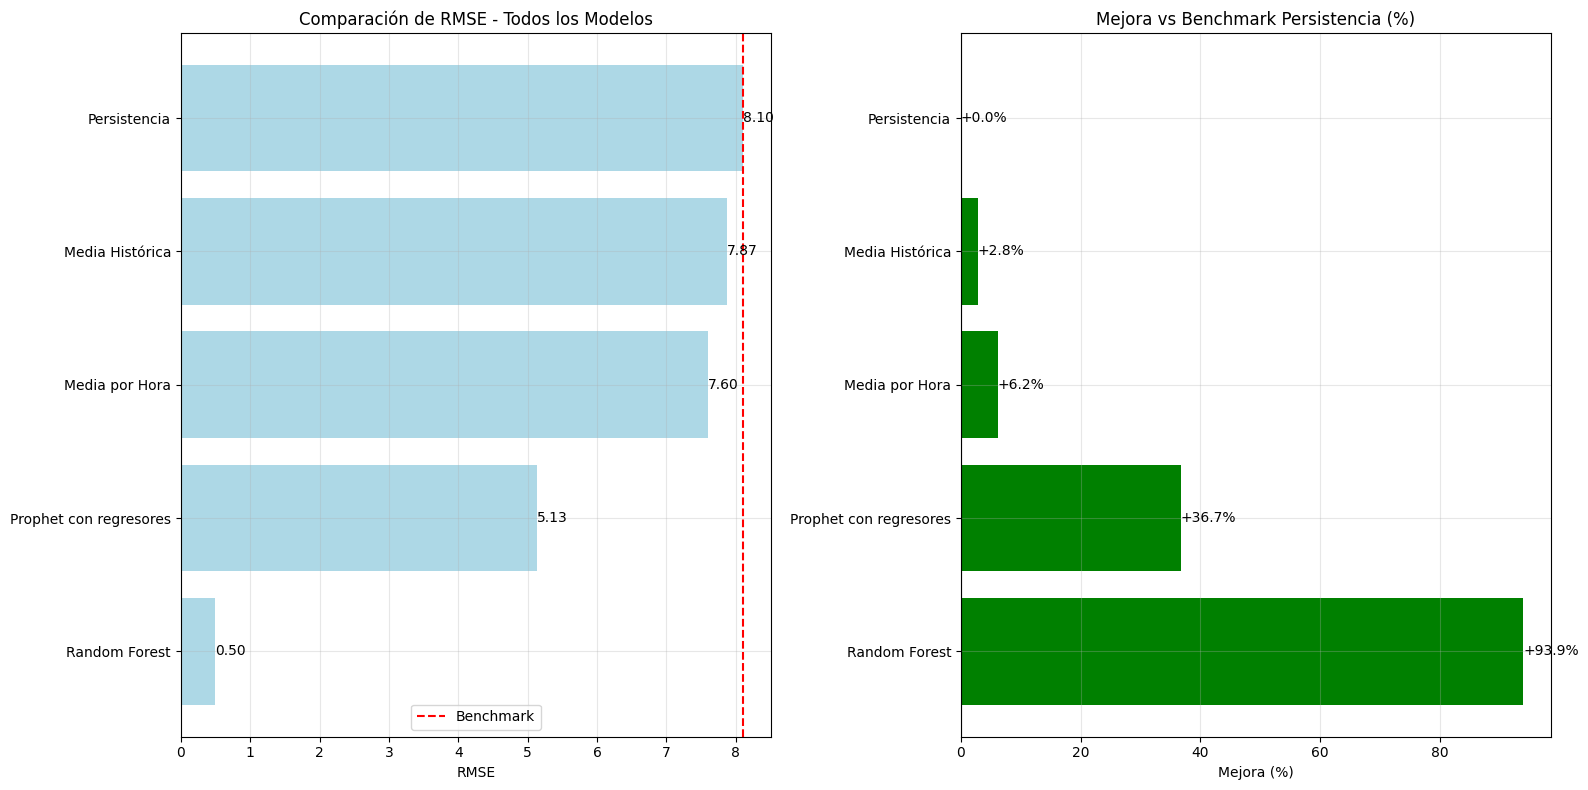


💡 RECOMENDACIONES:
1. Modelo principal: Random Forest
2. Error típico: 0.5 unidades de PM10
3. Mejora vs baseline: +93.9%


In [20]:
print("=== COMPARACIÓN FINAL ===")

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados).sort_values('RMSE')
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS (ordenados por RMSE)")
print("="*60)
print(df_resultados.round(4))

# Análisis
mejor_modelo = df_resultados.iloc[0]
mejor_benchmark = df_resultados[df_resultados['Modelo'] == 'Persistencia'].iloc[0]

mejora = ((mejor_benchmark['RMSE'] - mejor_modelo['RMSE']) / mejor_benchmark['RMSE']) * 100

print(f"\n🏆 RESUMEN:")
print(f"MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"  - RMSE: {mejor_modelo['RMSE']:.2f}")
print(f"  - MAE: {mejor_modelo['MAE']:.2f}")
print(f"BENCHMARK (Persistencia): RMSE = {mejor_benchmark['RMSE']:.2f}")
print(f"MEJORA: {mejora:+.1f}%")

# Gráfica comparativa final
plt.figure(figsize=(16, 8))

# Subplot 1: Performance comparativa
plt.subplot(1, 2, 1)
modelos_plot = df_resultados['Modelo'].values
rmse_plot = df_resultados['RMSE'].values

bars = plt.barh(range(len(modelos_plot)), rmse_plot, color='lightblue')
plt.yticks(range(len(modelos_plot)), modelos_plot)
plt.axvline(x=mejor_benchmark['RMSE'], color='red', linestyle='--', label='Benchmark')
plt.title('Comparación de RMSE - Todos los Modelos')
plt.xlabel('RMSE')
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', 
             ha='left', va='center')

plt.legend()

# Subplot 2: Mejora vs Benchmark
plt.subplot(1, 2, 2)
mejoras = []
for _, row in df_resultados.iterrows():
    mejora_modelo = ((mejor_benchmark['RMSE'] - row['RMSE']) / mejor_benchmark['RMSE']) * 100
    mejoras.append(mejora_modelo)

colors = ['green' if x >= 0 else 'red' for x in mejoras]
bars2 = plt.barh(range(len(modelos_plot)), mejoras, color=colors)
plt.yticks(range(len(modelos_plot)), modelos_plot)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.title('Mejora vs Benchmark Persistencia (%)')
plt.xlabel('Mejora (%)')
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for bar in bars2:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:+.1f}%', 
             ha='left' if width >= 0 else 'right', 
             va='center')

plt.tight_layout()
plt.show()

print(f"\n💡 RECOMENDACIONES:")
print(f"1. Modelo principal: {mejor_modelo['Modelo']}")
print(f"2. Error típico: {mejor_modelo['RMSE']:.1f} unidades de PM10")
print(f"3. Mejora vs baseline: {mejora:+.1f}%")